In [48]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [49]:
initial_investment = 10000
days = int(input("Enter the number of days:"))
mean_return = 0.0005
volatility = 0.02
num_simulations = int(input("Enter the number of simulations:"))
final_values = []

Enter the number of days: 252
Enter the number of simulations: 1000


In [50]:
def simulate_prices():
    for simulation in range(num_simulations):
        portfolio = initial_investment

        for day in range(days):
            daily_return = np.random.normal(mean_return, volatility)
            portfolio = portfolio * (1 + daily_return)

        final_values.append(portfolio)
simulate_prices()

In [51]:
def risk_metrics(final_values, initial_investment):
    var_95 = np.percentile(final_values, 5)
    var_95 = round(var_95, 2)
    var_95_loss = initial_investment - var_95
    print("95 VaR:", var_95_loss)

    tail_values = [value for value in final_values if value <= var_95]
    expected_shortfall = np.mean(tail_values)
    print(f"95% Expected Shortfall: ${expected_shortfall:.2f}")
risk_metrics(final_values, initial_investment)

95 VaR: 3596.51
95% Expected Shortfall: $5606.27


In [52]:
def summarize_results(final_values, initial_investment):
    print(f"Average final value: ${np.mean(final_values):,.2f}")
    print(f"Median final price: ${np.median(final_values):,.2f}")
    print(f"Lowest price: ${np.min(final_values):,.2f}")
    print(f"Highest price: ${np.max(final_values):,.2f}")
    prob_lose = np.sum(np.array(final_values) < initial_investment) / len(final_values)
    print(f"Probability of losing money: {prob_lose:.2%}")
    prob_gain = np.sum(np.array(final_values) > initial_investment) / len(final_values)
    print(f"Probability of gaining money: {prob_gain:.2%}")
summarize_results(final_values, initial_investment)

Average final value: $11,497.32
Median final price: $10,905.15
Lowest price: $3,666.55
Highest price: $29,515.30
Probability of losing money: 39.00%
Probability of gaining money: 61.00%


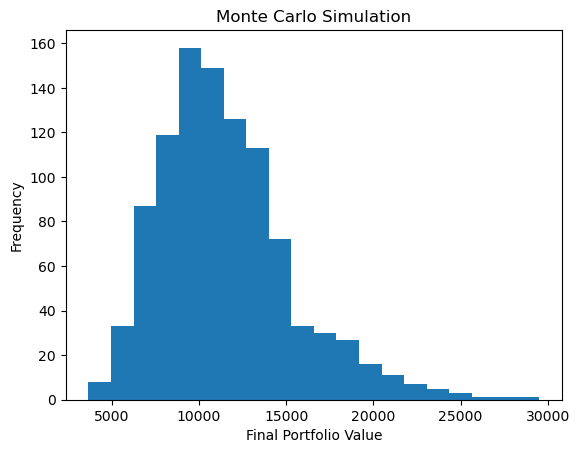

In [56]:
def plot_paths(final_values):
    plt.hist(final_values, bins = 20)
    plt.title("Monte Carlo Simulation")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Frequency")
    plt.show()
plot_paths(final_values)